# Chest X-Ray Classification using Multi-Backbone CNN (DenseNet121 + ResNet50)

This notebook classifies chest X-ray images from the **NIH Chest X-Ray dataset** into 3 classes:
- **No Finding** (healthy) - downsampled to 4000
- **Atelectasis** (disease)
- **Effusion** (disease)

Only single-label images are used. Three pretrained backbones (DenseNet121, ResNet50) are combined as feature extractors with a custom classification head. Training is done in two phases:
1. **Phase 1** - Frozen backbones, train classifier head only
2. **Phase 2** - Fine-tune last layers of all backbones

Mixed precision (float16) is used for faster training. Light data augmentation is applied. Dataset is split 80% train, 10% validation, 10% test.

## Imports

In [1]:
import pandas as pd
import numpy as np
import os, glob, cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import DenseNet121, ResNet50, ConvNeXtBase
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-03-28 08:41:33.120163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774687293.322311      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774687293.377845      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774687293.869221      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687293.869258      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687293.869260      23 computation_placer.cc:177] computation placer alr

## Enable mixed precision

In [2]:
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", mixed_precision.global_policy())
print("GPUs available:", tf.config.list_physical_devices('GPU'))

Mixed precision policy: <DTypePolicy "mixed_float16">
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Config

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
DISEASE_CLASSES = ["Atelectasis", "Effusion", "No Finding"]
NUM_CLASSES = len(DISEASE_CLASSES)
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 15

## Load CSV

In [4]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


## Select columns & map image paths

In [5]:
df = df[[
    'Image Index',
    'Finding Labels',
    'Follow-up #',
    'Patient ID',
    'Patient Age',
    'Patient Gender',
    'View Position'
]].copy()
df.columns = [
    'image_path',
    'labels',
    'followup_num',
    'patient_id',
    'age',
    'gender',
    'view_position'
]
BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
all_images = glob.glob(os.path.join(BASE_DIR, "images_*", "images", "*.png"))
path_dict = {os.path.basename(x): x for x in all_images}
df["image_path"] = df["image_path"].map(path_dict)
df.head(3)

,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Emphysema,1,1,58,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Effusion,2,1,58,M,PA


## Clean age outliers

In [6]:
print("Age stats before cleaning:")
print(df['age'].describe())

df = df[df['age'] <= 120].reset_index(drop=True)

print("Rows after age cleaning:", len(df))

Age stats before cleaning:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: age, dtype: float64
Rows after age cleaning: 112104


## Keep Single-Label Only

In [7]:
multi_mask = df["labels"].str.contains("\\|")
print(f"Multi-label rows : {multi_mask.sum():,}")
print(f"Single-label rows: {(~multi_mask).sum():,}")

df = df[~multi_mask].copy().reset_index(drop=True)
print(f"\nWorking dataframe shape: {df.shape}")
df.head()

Multi-label rows : 20,792
Single-label rows: 91,312

Working dataframe shape: (91312, 7)


,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,No Finding,0,2,81,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Hernia,0,3,81,F,PA
3,/kaggle/input/datasets/organizations/nih-chest...,Hernia,1,3,74,F,PA
4,/kaggle/input/datasets/organizations/nih-chest...,Hernia,2,3,75,F,PA


## Data Visualization (Single Label)

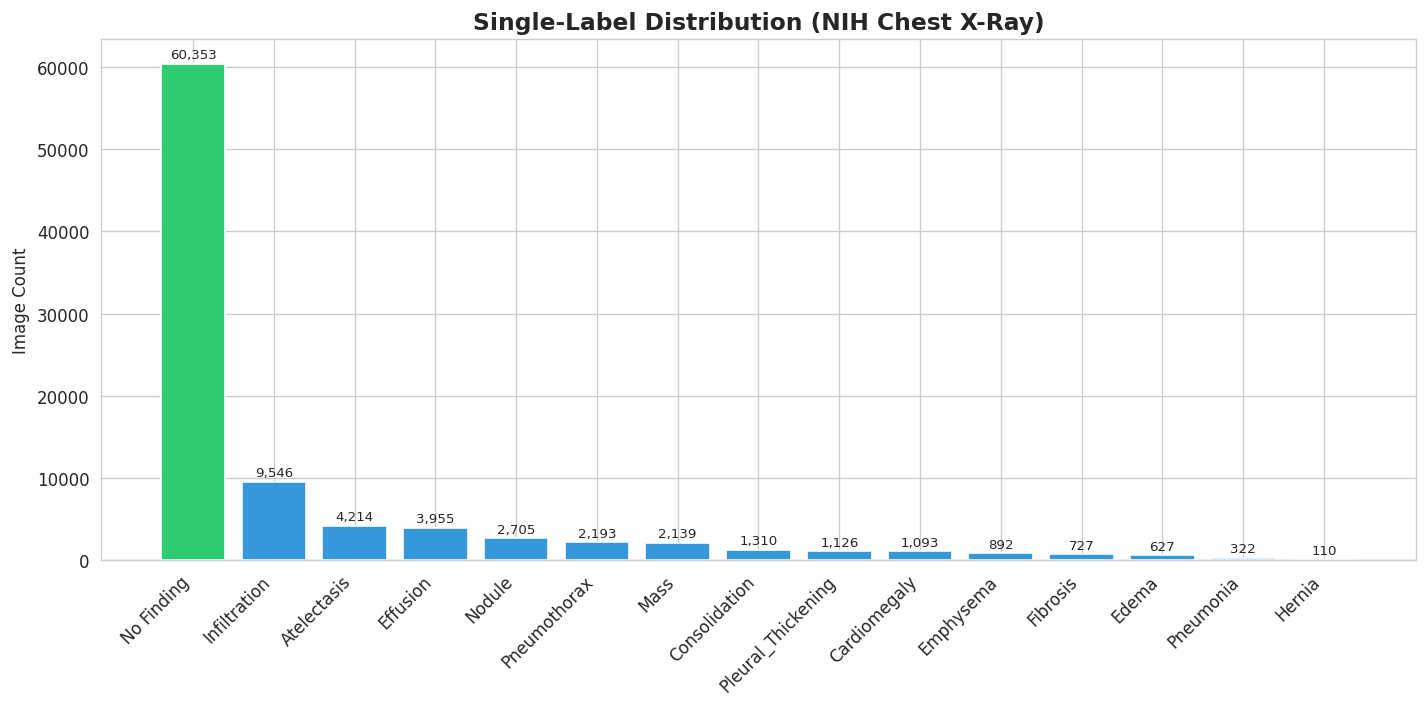

In [8]:
label_counts = df["labels"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ecc71" if l == "No Finding" else "#3498db" for l in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{val:,}", ha="center", va="bottom", fontsize=8)

ax.set_title("Single-Label Distribution (NIH Chest X-Ray)", fontsize=14, weight="bold")
ax.set_ylabel("Image Count")

ax.set_xticks(range(len(label_counts.index)))
ax.set_xticklabels(label_counts.index, rotation=45, ha="right")

plt.tight_layout()
plt.show()

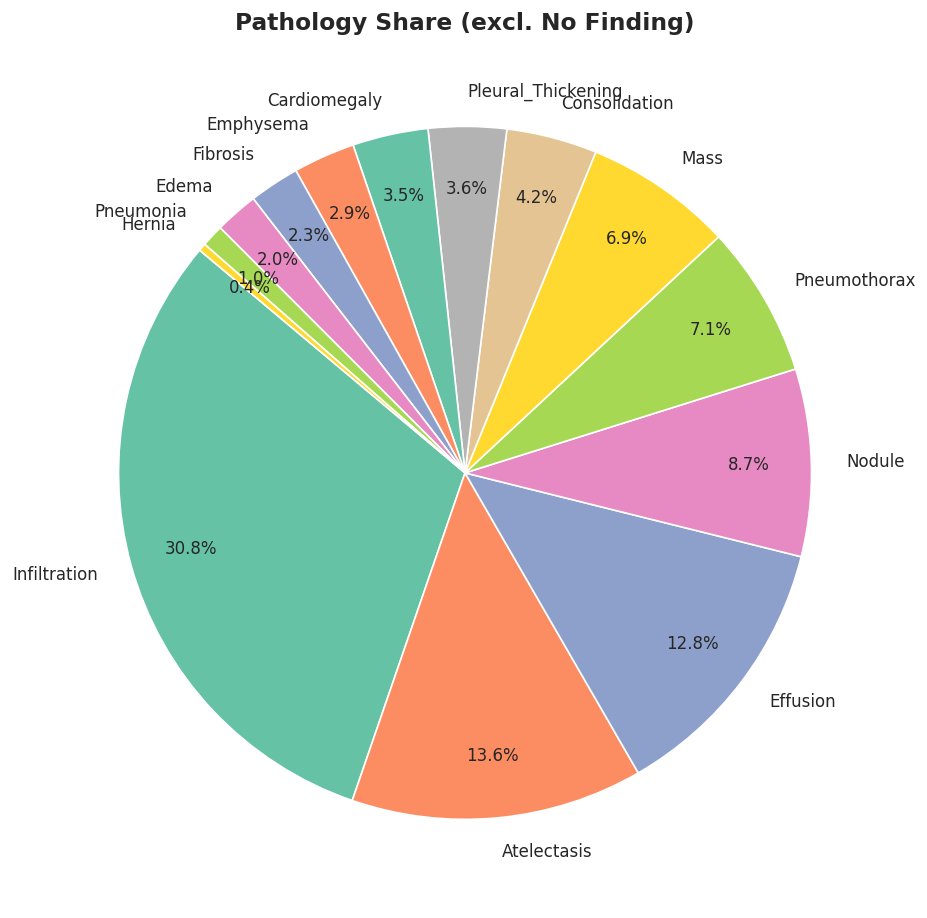

In [9]:
pathology = label_counts.drop("No Finding")

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    pathology.values, labels=pathology.index, autopct="%1.1f%%",
    startangle=140, pctdistance=0.82,
    colors=sns.color_palette("Set2", len(pathology))
)
ax.set_title("Pathology Share (excl. No Finding)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [10]:
no_finding_count = label_counts["No Finding"]
pathology_total  = label_counts.drop("No Finding").sum()

print(f"No Finding   : {no_finding_count:>7,}  ({no_finding_count/len(df)*100:.1f}%)")
print(f"All Pathology: {pathology_total:>7,}  ({pathology_total/len(df)*100:.1f}%)")

No Finding   :  60,353  (66.1%)
All Pathology:  30,959  (33.9%)


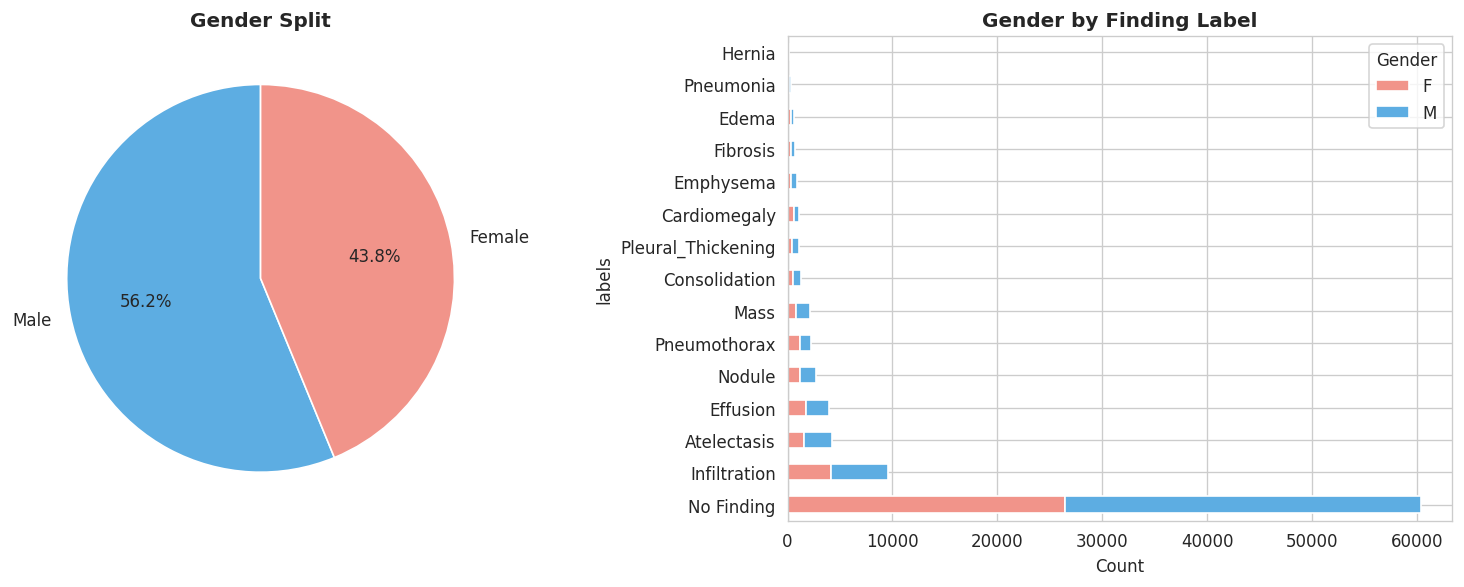

In [11]:
gender_counts = df["gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(gender_counts.values, labels=["Male", "Female"],
            autopct="%1.1f%%", colors=["#5dade2", "#f1948a"], startangle=90)
axes[0].set_title("Gender Split", weight="bold")

gender_label = df.groupby(["labels", "gender"]).size().unstack(fill_value=0)
gender_label = gender_label.loc[label_counts.index]
gender_label.plot(kind="barh", stacked=True, ax=axes[1],
                  color=["#f1948a", "#5dade2"], edgecolor="white")
axes[1].set_title("Gender by Finding Label", weight="bold")
axes[1].set_xlabel("Count")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

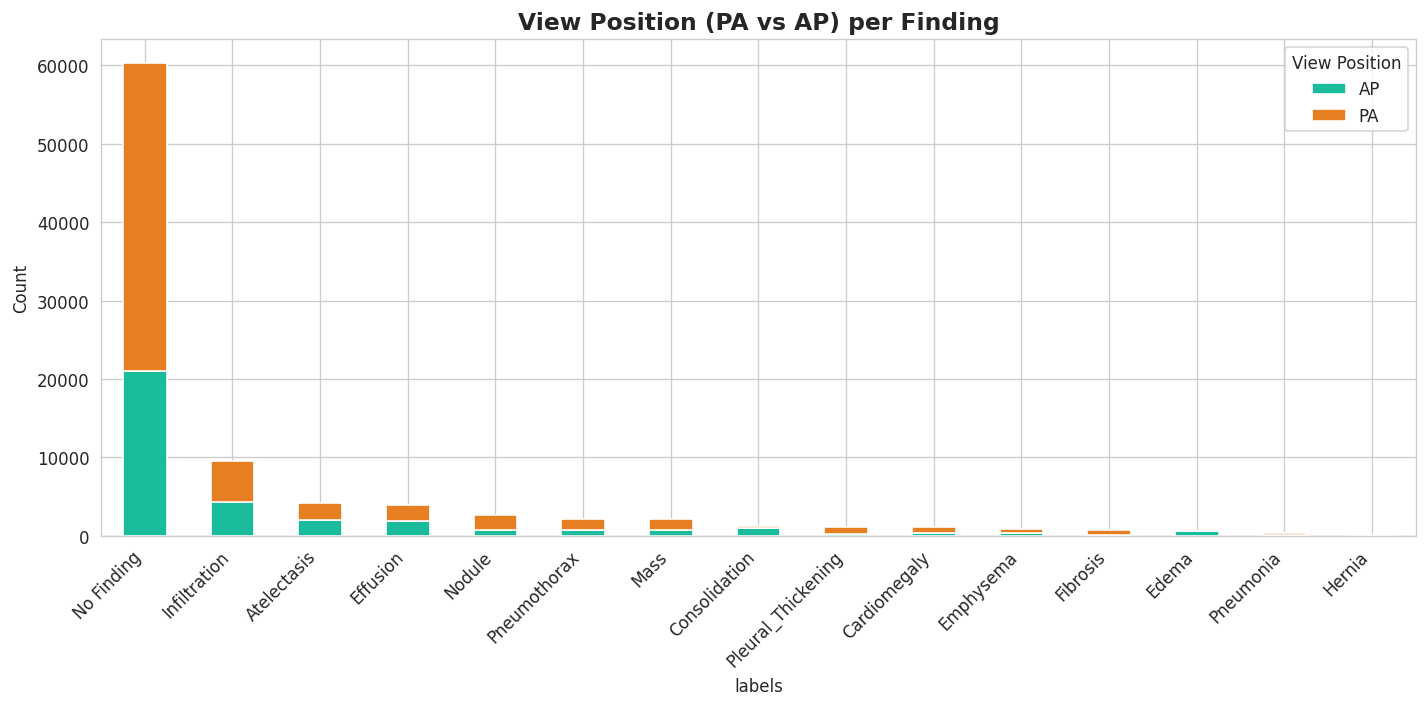

In [12]:
vp_label = df.groupby(["labels", "view_position"]).size().unstack(fill_value=0)
vp_label = vp_label.loc[label_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
vp_label.plot(kind="bar", stacked=True, ax=ax,
              color=["#1abc9c", "#e67e22"], edgecolor="white")
ax.set_title("View Position (PA vs AP) per Finding", fontsize=14, weight="bold")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="View Position")
plt.tight_layout()
plt.show()

In [13]:
patients_per_label = df.groupby("labels")["patient_id"].nunique().reindex(label_counts.index)
images_per_label   = label_counts

ratio = (images_per_label / patients_per_label).round(2)

summary = pd.DataFrame({
    "Images": images_per_label,
    "Unique Patients": patients_per_label,
    "Images / Patient": ratio
})
summary

,Images,Unique Patients,Images / Patient
labels,,,
No Finding,60353,24905,2.42
Infiltration,9546,5465,1.75
Atelectasis,4214,2642,1.60
Effusion,3955,1984,1.99
Nodule,2705,1890,1.43
Pneumothorax,2193,934,2.35
Mass,2139,1360,1.57
Consolidation,1310,847,1.55
Pleural_Thickening,1126,891,1.26


## Balance the 3 classes (No Finding, Atelectasis, Effusion)

In [14]:
df_no_finding = df[df["labels"] == "No Finding"]
df_atelectasis = df[df["labels"] == "Atelectasis"]
df_effusion = df[df["labels"] == "Effusion"]

df_no_finding_sampled = df_no_finding.sample(n=4000, random_state=RANDOM_SEED)

df_balanced = pd.concat([
    df_no_finding_sampled,
    df_atelectasis,
    df_effusion
]).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(df_balanced["labels"].value_counts())
print(f"Final shape: {df_balanced.shape}")

labels
Atelectasis    4214
No Finding     4000
Effusion       3955
Name: count, dtype: int64
Final shape: (12169, 7)


## Encode labels & split 80/10/10

In [15]:
# Encode labels as integers
label_map = {name: idx for idx, name in enumerate(DISEASE_CLASSES)}
df_balanced["label_idx"] = df_balanced["labels"].map(label_map)
print("Label mapping:", label_map)

# Get unique patients with their labels
patient_labels = df_balanced.groupby("patient_id")["label_idx"].first().reset_index()

# First split: 80% train, 20% temp (patient-wise)
train_patients, temp_patients = train_test_split(
    patient_labels["patient_id"].values,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=patient_labels["label_idx"].values
)

# Second split: 50/50 of temp → 10% val, 10% test
temp_labels = patient_labels[patient_labels["patient_id"].isin(temp_patients)]
val_patients, test_patients = train_test_split(
    temp_labels["patient_id"].values,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_labels["label_idx"].values
)

# Map patients back to images
train_mask = df_balanced["patient_id"].isin(train_patients)
val_mask = df_balanced["patient_id"].isin(val_patients)
test_mask = df_balanced["patient_id"].isin(test_patients)

X_train_paths = df_balanced.loc[train_mask, "image_path"].values
y_train = df_balanced.loc[train_mask, "label_idx"].values

X_val_paths = df_balanced.loc[val_mask, "image_path"].values
y_val = df_balanced.loc[val_mask, "label_idx"].values

X_test_paths = df_balanced.loc[test_mask, "image_path"].values
y_test = df_balanced.loc[test_mask, "label_idx"].values

# Summary
print(f"\nUnique patients — Train: {len(train_patients)} | Val: {len(val_patients)} | Test: {len(test_patients)}")
print(f"Images — Train: {len(X_train_paths)} | Val: {len(X_val_paths)} | Test: {len(X_test_paths)}")
print(f"\nTrain distribution: {np.bincount(y_train)}")
print(f"Val distribution:   {np.bincount(y_val)}")
print(f"Test distribution:  {np.bincount(y_test)}")

# Verify no patient overlap
assert len(set(train_patients) & set(val_patients)) == 0, "Leak between train and val!"
assert len(set(train_patients) & set(test_patients)) == 0, "Leak between train and test!"
assert len(set(val_patients) & set(test_patients)) == 0, "Leak between val and test!"
print("\nNo patient leakage — all splits are clean!")

Label mapping: {'Atelectasis': 0, 'Effusion': 1, 'No Finding': 2}

Unique patients — Train: 5322 | Val: 665 | Test: 666
Images — Train: 9676 | Val: 1261 | Test: 1232

Train distribution: [3370 3116 3190]
Val distribution:   [422 426 413]
Test distribution:  [422 413 397]

No patient leakage — all splits are clean!


## Compute Class Weights

In [16]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9570722057368941), 1: np.float64(1.0350877192982457), 2: np.float64(1.0110762800417974)}


## Data augmentation & dataset pipeline

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),          
    layers.RandomZoom((-0.05, 0.05)),    
    layers.RandomBrightness(0.1),         
    layers.RandomContrast(0.1),          
], name="augmentation")

def load_and_preprocess(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  
    return img, label

def create_dataset(paths, labels, batch_size, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(X_train_paths, y_train, BATCH_SIZE, augment=True, shuffle=True)
val_ds = create_dataset(X_val_paths, y_val, BATCH_SIZE)
test_ds = create_dataset(X_test_paths, y_test, BATCH_SIZE)

print("Datasets created!")

I0000 00:00:1774687319.670293      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774687319.676484      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created!


## Build multi-backbone model

In [18]:
def build_model():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    # Backbone 1: DenseNet121
    densenet_base = DenseNet121(weights="imagenet", include_top=False,
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    densenet_base.trainable = False
    for layer in densenet_base.layers:
        layer._name = "densenet_" + layer.name
    densenet_out = densenet_base(inp)
    densenet_pool = layers.GlobalAveragePooling2D(name="densenet_gap")(densenet_out)

    # Backbone 2: ResNet50
    resnet_base = ResNet50(weights="imagenet", include_top=False,
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))
    resnet_base.trainable = False
    for layer in resnet_base.layers:
        layer._name = "resnet_" + layer.name
    resnet_out = resnet_base(inp)
    resnet_pool = layers.GlobalAveragePooling2D(name="resnet_gap")(resnet_out)

    # Combine: 1024 + 2048 = 3072
    combined = layers.Concatenate(name="concat")([densenet_pool, resnet_pool])

    # Classifier head
    x = layers.Dense(512, activation="relu", name="fc1")(combined)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(0.5, name="drop1")(x)

    x = layers.Dense(256, activation="relu", name="fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)

    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32",
        name="output"
    )(x)

    model = Model(inputs=inp, outputs=output, name="DualBackbone_Classifier")
    return model, densenet_base, resnet_base

model, densenet_base, resnet_base = build_model()
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DualBackbone_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_image[0][0] │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_image[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_gap        │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_gap          │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 3072)      │          0 │ densenet_gap[0][… │
│ (Concatenate)       │                   │            │ resnet_gap[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 512)       │  1,573,376 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 512)       │      2,048 │ fc1[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 512)       │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 256)       │    131,328 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 256)       │      1,024 │ fc2[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 256)       │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        771 │ drop2[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,333,763 (123.34 MB)

 Trainable params: 1,707,011 (6.51 MB)

 Non-trainable params: 30,626,752 (116.83 MB)

## Phase 1: Train classifier head only (frozen backbones)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

print("=" * 50)
print("PHASE 1: Training classifier head (backbones frozen)")
print("=" * 50)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1
)

PHASE 1: Training classifier head (backbones frozen)
Epoch 1/15


I0000 00:00:1774687348.165794      73 service.cc:152] XLA service 0x78a640032980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774687348.165874      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774687348.165882      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774687354.749266      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/303 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.3359 - loss: 1.7593   

I0000 00:00:1774687374.371324      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


303/303 ━━━━━━━━━━━━━━━━━━━━ 231s 606ms/step - accuracy: 0.4691 - loss: 1.3314 - val_accuracy: 0.4409 - val_loss: 1.3030 - learning_rate: 0.0010
Epoch 2/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 116s 379ms/step - accuracy: 0.5176 - loss: 1.0242 - val_accuracy: 0.4822 - val_loss: 1.1637 - learning_rate: 0.0010
Epoch 3/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 117s 381ms/step - accuracy: 0.5346 - loss: 0.9729 - val_accuracy: 0.5282 - val_loss: 1.0027 - learning_rate: 0.0010
Epoch 4/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 115s 378ms/step - accuracy: 0.5525 - loss: 0.9369 - val_accuracy: 0.3862 - val_loss: 1.7098 - learning_rate: 0.0010
Epoch 5/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 116s 379ms/step - accuracy: 0.5754 - loss: 0.9177 - val_accuracy: 0.5139 - val_loss: 1.0070 - learning_rate: 0.0010
Epoch 6/15
302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5666 - loss: 0.9136
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
303/303 ━━━━━━━━━━━━━━━━━━━━ 116s 379ms/step - accuracy: 0.5666 - l

## Phase 2: Fine-tune last layers of all backbones

In [20]:
# Unfreeze last layers of each backbone
# DenseNet121: unfreeze last 30 layers
for layer in densenet_base.layers[-30:]:
    layer.trainable = True

# ResNet50: unfreeze last 30 layers
for layer in resnet_base.layers[-30:]:
    layer.trainable = True

trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
print(f"Trainable params:     {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")

# Lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy",]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_model.keras", monitor='val_loss', save_best_only=True, verbose=1),
]

print("=" * 50)
print("PHASE 2: Fine-tuning backbone layers")
print("=" * 50)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2
)

Trainable params:     16,798,595
Non-trainable params: 15,535,168
PHASE 2: Fine-tuning backbone layers
Epoch 1/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.5530 - loss: 0.9396
Epoch 1: val_loss improved from inf to 0.99693, saving model to best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 233s 567ms/step - accuracy: 0.5530 - loss: 0.9396 - val_accuracy: 0.5377 - val_loss: 0.9969 - learning_rate: 1.0000e-05
Epoch 2/15
302/303 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.5761 - loss: 0.9001
Epoch 2: val_loss improved from 0.99693 to 0.99061, saving model to best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 120s 394ms/step - accuracy: 0.5761 - loss: 0.9001 - val_accuracy: 0.5369 - val_loss: 0.9906 - learning_rate: 1.0000e-05
Epoch 3/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.5834 - loss: 0.8933
Epoch 3: val_loss did not improve from 0.99061
303/303 ━━━━━━━━━━━━━━━━━━━━ 117s 383ms/step - accuracy: 0.5834 - loss: 0.8933 - val_accuracy: 0.5385 - val_loss: 0.9973 -

## Plot training history (both phases)

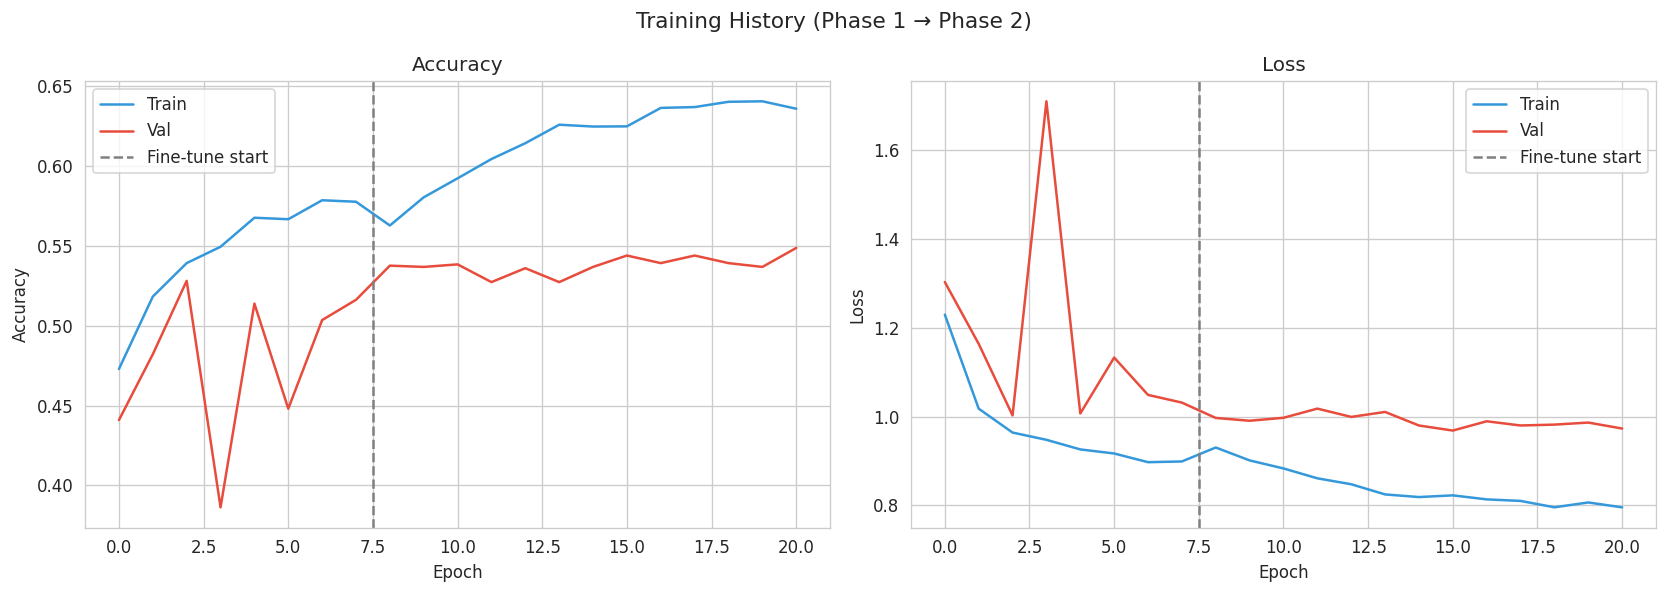

In [21]:
def plot_history(h1, h2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    phase1_epochs = len(h1.history['accuracy'])

    # Accuracy
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    axes[0].plot(acc, label='Train', color='#3498db')
    axes[0].plot(val_acc, label='Val', color='#e74c3c')
    axes[0].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # Loss
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    axes[1].plot(loss, label='Train', color='#3498db')
    axes[1].plot(val_loss, label='Val', color='#e74c3c')
    axes[1].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.suptitle("Training History (Phase 1 → Phase 2)", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history_phase1, history_phase2)

## Evaluate on test set

In [22]:
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating on test set...
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 689ms/step - accuracy: 0.5785 - loss: 0.9025

Test Loss: 0.9141
Test Accuracy: 0.5747


##  Predictions & classification report

In [23]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=DISEASE_CLASSES))

39/39 ━━━━━━━━━━━━━━━━━━━━ 36s 549ms/step
Classification Report:

              precision    recall  f1-score   support

 Atelectasis       0.49      0.64      0.55       422
    Effusion       0.69      0.53      0.60       413
  No Finding       0.61      0.55      0.58       397

    accuracy                           0.57      1232
   macro avg       0.60      0.57      0.58      1232
weighted avg       0.59      0.57      0.58      1232



## Confusion matrix

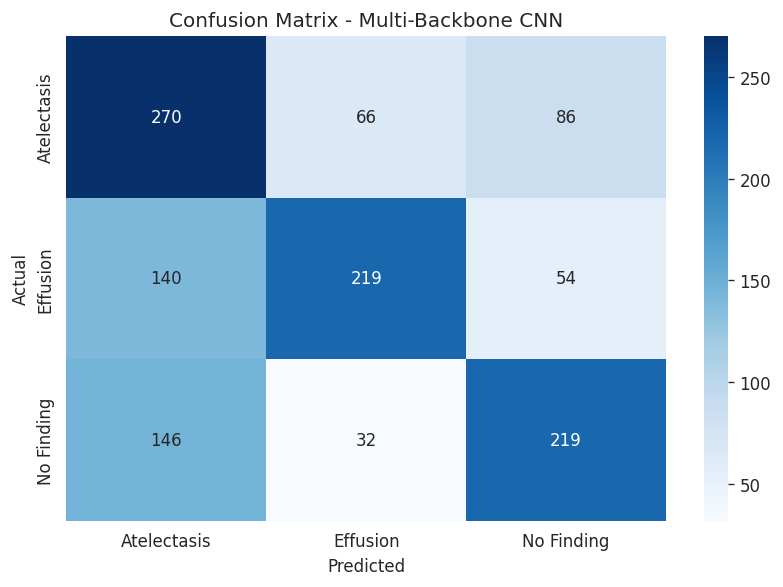

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISEASE_CLASSES,
            yticklabels=DISEASE_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multi-Backbone CNN")
plt.tight_layout()
plt.show()

##  ROC curves (one per class)

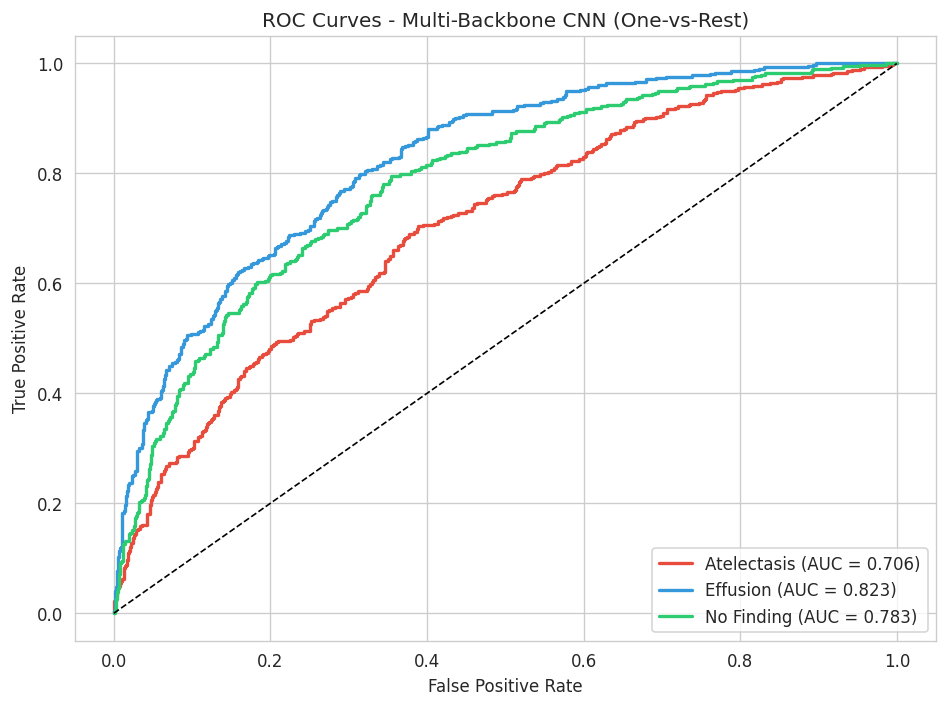

Macro AUC: 0.7706


In [25]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, cls_name in enumerate(DISEASE_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{cls_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-Backbone CNN (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_probs, multi_class='ovr', average='macro')
print(f"Macro AUC: {macro_auc:.4f}")

## Per-class accuracy bar chart

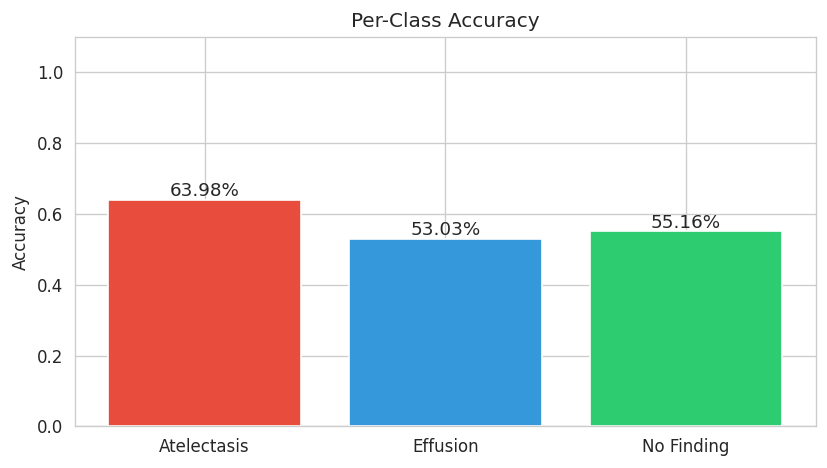

In [26]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7, 4))
bars = plt.bar(DISEASE_CLASSES, per_class_acc, color=['#e74c3c', '#3498db', '#2ecc71'])
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.2%}", ha='center', fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()

## Visualize correct & incorrect predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


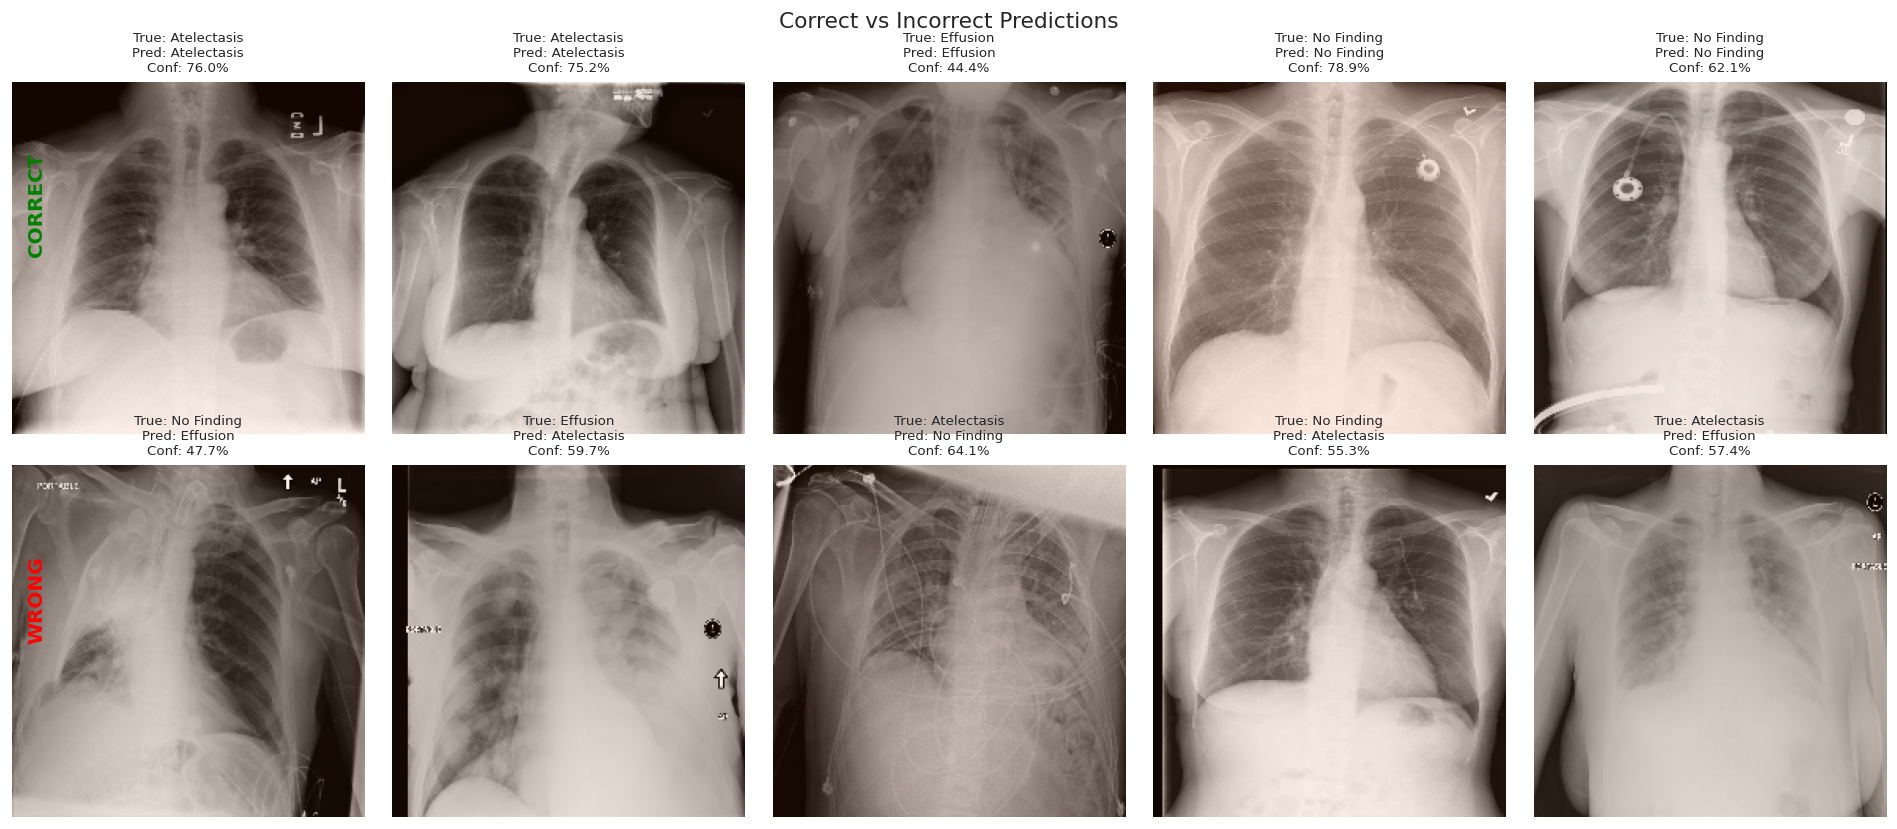

In [27]:
# Get a batch from test set
test_images, test_labels = next(iter(test_ds))
preds = model.predict(test_images)
pred_classes = np.argmax(preds, axis=1)

# Find correct and incorrect
correct_mask = pred_classes == test_labels.numpy()
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Top row: correct predictions
fig.text(0.02, 0.75, "CORRECT", fontsize=12, fontweight='bold', color='green', rotation=90, va='center')
correct_indices = np.where(correct_mask)[0][:5]
for i, idx in enumerate(correct_indices):
    img = test_images[idx].numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"True: {DISEASE_CLASSES[test_labels[idx]]}\n"
                         f"Pred: {DISEASE_CLASSES[pred_classes[idx]]}\n"
                         f"Conf: {preds[idx][pred_classes[idx]]:.1%}", fontsize=8)
    axes[0, i].axis('off')

# Bottom row: incorrect predictions
fig.text(0.02, 0.28, "WRONG", fontsize=12, fontweight='bold', color='red', rotation=90, va='center')
incorrect_indices = np.where(incorrect_mask)[0][:5]
for i, idx in enumerate(incorrect_indices):
    img = test_images[idx].numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"True: {DISEASE_CLASSES[test_labels[idx]]}\n"
                         f"Pred: {DISEASE_CLASSES[pred_classes[idx]]}\n"
                         f"Conf: {preds[idx][pred_classes[idx]]:.1%}", fontsize=8)
    axes[1, i].axis('off')

# Fill empty slots if not enough samples
for row in range(2):
    filled = len(correct_indices) if row == 0 else len(incorrect_indices)
    for i in range(filled, 5):
        axes[row, i].axis('off')

plt.suptitle("Correct vs Incorrect Predictions", fontsize=13)
plt.tight_layout()
plt.show()

## Prediction confidence distribution

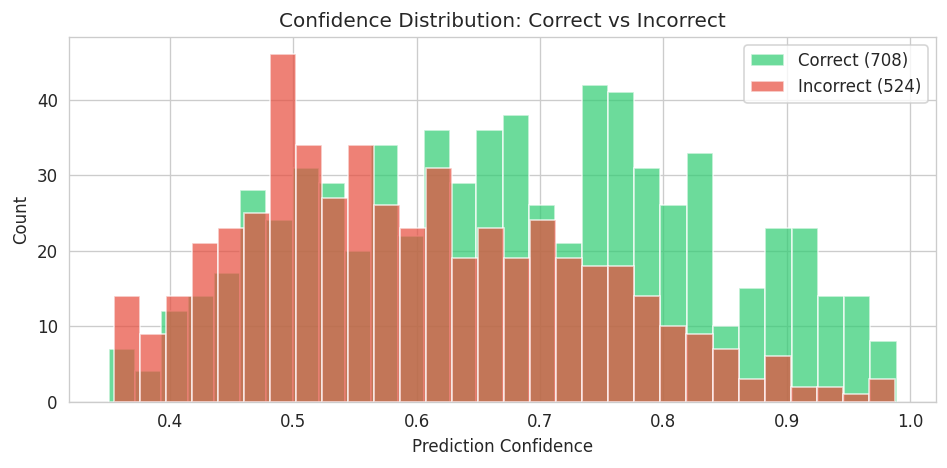

In [28]:
max_confidences = np.max(y_pred_probs, axis=1)
correct_conf = max_confidences[y_pred == y_test]
incorrect_conf = max_confidences[y_pred != y_test]

plt.figure(figsize=(8, 4))
plt.hist(correct_conf, bins=30, alpha=0.7, label=f"Correct ({len(correct_conf)})", color='#2ecc71')
plt.hist(incorrect_conf, bins=30, alpha=0.7, label=f"Incorrect ({len(incorrect_conf)})", color='#e74c3c')
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()